IMPORTING LIBRARIES AND DATASETS


In [2]:
import pandas as pd

file_path= 'C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Largest-Companies/Datasets/Largest-Companies.csv'
df= pd.read_csv(file_path, encoding='ISO-8859-1')

In [3]:
df.head(15)

,Rank,Name,Sales,Profit,Assets,Market Value,Industry,Founded,Headquarters,Country,CEO,Employees
0,1,JPMorgan Chase,252.9,50.0,4090.7,588.1,Banking and Financial Services,2000.0,New York- New York,United States,Jamie Dimon,186751.0
1,2,Berkshire Hathaway,369.0,73.4,1070.0,899.1,Conglomerate,1839.0,Omaha- Nebraska,United States,Warren Edward Buffett,396500.0
2,3,Saudi Arabian Oil Company (Saudi Aramco),489.1,116.9,661.5,1919.3,Construction- Chemicals- Raw Materials,1933.0,Dhahran,Saudi Arabia,Amin bin Hasan Al-Nasser,70000.0
3,4,ICBC,223.8,50.4,6586.0,215.2,Banking and Financial Services,1984.0,Beijing,China,Wang Jingwu,427587.0
4,5,Bank of America,183.3,25.0,3273.8,307.3,Banking and Financial Services,1904.0,Charlotte- North Carolina,United States,Brian T. Moynihan,166140.0
5,6,Amazon,590.7,37.7,531.0,1922.1,Retail and Wholesale,1994.0,Seattle- Washington,United States,Andrew R. Jassy,1525000.0
6,7,China Construction Bank,199.8,47.0,5403.8,187.5,Banking and Financial Services,1954.0,Beijing,China,Zhang Jianguo,376871.0
7,8,Microsoft,236.6,86.2,484.3,3123.1,IT Software & Services,1975.0,Redmond- Washington,United States,Satya Nadella,122000.0
8,9,Agricultural Bank of China,193.5,37.4,5832.9,170.9,Banking,1951.0,Beijing,China,Shu Gu,451003.0
9,10,Alphabet,317.9,82.4,407.4,2177.7,IT Software & Services,1998.0,Mountain View- California,United States,Sundar Pichai,182502.0


SUMMARY OF DATA INFORMATION


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          2001 non-null   int64  
 1   Name          2001 non-null   object 
 2   Sales         2001 non-null   float64
 3   Profit        2001 non-null   float64
 4   Assets        2001 non-null   float64
 5   Market Value  2001 non-null   float64
 6   Industry      1999 non-null   object 
 7   Founded       1999 non-null   float64
 8   Headquarters  1991 non-null   object 
 9   Country       2001 non-null   object 
 10  CEO           1970 non-null   object 
 11  Employees     1943 non-null   float64
dtypes: float64(6), int64(1), object(5)
memory usage: 187.7+ KB


In [5]:
df.describe()

,Rank,Sales,Profit,Assets,Market Value,Founded,Employees
count,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,1999.000000,1.943000e+03
mean,1001.000000,25.838675,2.248652,119.091304,44.204768,1966.408204,4.858326e+04
std,577.783264,46.583439,6.181587,388.317154,149.325120,407.847622,8.975563e+04
min,1.000000,0.123000,-17.900000,1.300000,0.007000,1472.000000,1.100000e+01
25%,501.000000,6.000000,0.486800,15.500000,8.000000,1926.000000,8.412000e+03
50%,1001.000000,12.700000,0.931000,33.600000,17.400000,1973.000000,2.160000e+04
75%,1501.000000,25.400000,2.100000,78.000000,37.800000,1997.000000,5.222600e+04
max,2001.000000,657.300000,116.900000,6586.000000,3123.100000,20047.000000,1.600000e+06


FINDING MISSING VALUES


In [6]:
missing_values= df.isnull().sum()
print(missing_values[missing_values > 0])

Industry         2
Founded          2
Headquarters    10
CEO             31
Employees       58
dtype: int64


EDA ON DATASET


In [7]:
country_counts= df['Country'].value_counts()
top_country= country_counts.head(10)
print(top_country)

Country
United States     621
China             282
Japan             181
India              70
United Kingdom     65
South Korea        61
Canada             59
France             50
Germany            50
Switzerland        46
Name: count, dtype: int64


In [8]:
industy_counts= df['Industry'].value_counts()
top_industry= industy_counts.head(10)
print(top_industry)

Industry
Banking                                   235
Diversified Financials                    116
Banking and Financial Services            114
Utilities                                 103
Insurance                                 102
Construction                               85
Construction- Chemicals- Raw Materials     83
IT Software & Services                     80
Engineering- Manufacturing                 64
Business Services & Supplies               62
Name: count, dtype: int64


In [9]:
# Separating industry's column values for proper analysis
import re
industry_dict= {}
for idx, row in df.iterrows():
    company_name= row['Name']
    industries= row['Industry']
    if pd.notna(industries):
        industries_list= re.split(r"- | & | and | And", industries)
        industries_list= [industry.strip() for industry in industries_list]
    else:
        industries_list= []
    industry_dict[company_name]= industries_list
for company, industries in list(industry_dict.items())[:20]:
    print(f"{company}:{industries}")

JPMorgan Chase:['Banking', 'Financial Services']
Berkshire Hathaway:['Conglomerate']
Saudi Arabian Oil Company (Saudi Aramco):['Construction', 'Chemicals', 'Raw Materials']
ICBC:['Banking', 'Financial Services']
Bank of America:['Banking', 'Financial Services']
Amazon:['Retail', 'Wholesale']
China Construction Bank:['Banking', 'Financial Services']
Microsoft:['IT Software', 'Services']
Agricultural Bank of China:['Banking']
Alphabet:['IT Software', 'Services']
Toyota Motor:['Consumer Durables']
Apple:['Semiconductors', 'Electronics', 'Electrical Engineering']
Bank of China:['Banking']
ExxonMobil:['Construction', 'Chemicals', 'Raw Materials']
HSBC Holdings:['Business Services', 'Supplies']
Wells Fargo:['Banking', 'Financial Services']
Shell Plc:['Construction', 'Chemicals', 'Raw Materials']
PetroChina:['Oil', 'Gas Operations']
UnitedHealth Group:['Insurance']
Walmart:['Pharmacies']


In [10]:
top_profit_ceos= df.sort_values(by='Profit', ascending=False)[['CEO', 'Name', 'Profit']]
top_profit_ceos= top_profit_ceos.head(10)
print(top_profit_ceos)

                         CEO                                      Name  Profit
2   Amin bin Hasan Al-Nasser  Saudi Arabian Oil Company (Saudi Aramco)   116.9
11                  Tim Cook                                     Apple   100.4
7              Satya Nadella                                 Microsoft    86.2
9              Sundar Pichai                                  Alphabet    82.4
1      Warren Edward Buffett                        Berkshire Hathaway    73.4
3                Wang Jingwu                                      ICBC    50.4
0                Jamie Dimon                            JPMorgan Chase    50.0
6              Zhang Jianguo                   China Construction Bank    47.0
23    Mark Elliot Zuckerberg                            Meta Platforms    45.8
5            Andrew R. Jassy                                    Amazon    37.7


In [11]:
numeric_df= df.select_dtypes(include=['float64'])

correlation_matrix= numeric_df.corr()
print(correlation_matrix)

                 Sales    Profit    Assets  Market Value   Founded  Employees
Sales         1.000000  0.661865  0.381110      0.517937 -0.017720   0.651032
Profit        0.661865  1.000000  0.461375      0.808203 -0.009862   0.326400
Assets        0.381110  0.461375  1.000000      0.140647 -0.014950   0.237727
Market Value  0.517937  0.808203  0.140647      1.000000 -0.005238   0.279590
Founded      -0.017720 -0.009862 -0.014950     -0.005238  1.000000  -0.016049
Employees     0.651032  0.326400  0.237727      0.279590 -0.016049   1.000000


DATA VISULIZATION


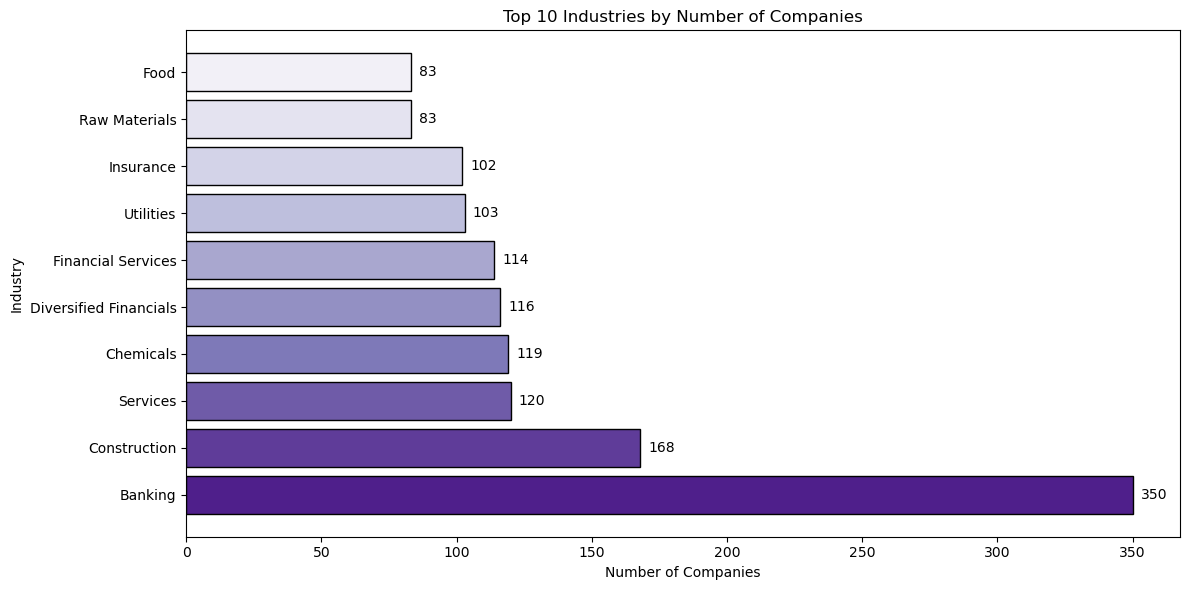

In [13]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

industry_counter= Counter()
for industries in industry_dict.values():
    industry_counter.update(industries)
top_industries= industry_counter.most_common(10)
industries, counts= zip(*top_industries)
colors= plt.cm.Purples(np.linspace(0.9, 0.1, len(counts)))

plt.figure(figsize=(12,6))
bars= plt.barh(industries, counts, color= colors, edgecolor='black')
plt.ylabel("Industry")
plt.xlabel("Number of Companies")
plt.title("Top 10 Industries by Number of Companies")

for bar, count in zip (bars, counts):
    xval= bar.get_width()
    plt.text(xval + 3, bar.get_y() + bar.get_height() / 2, f'{count}', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

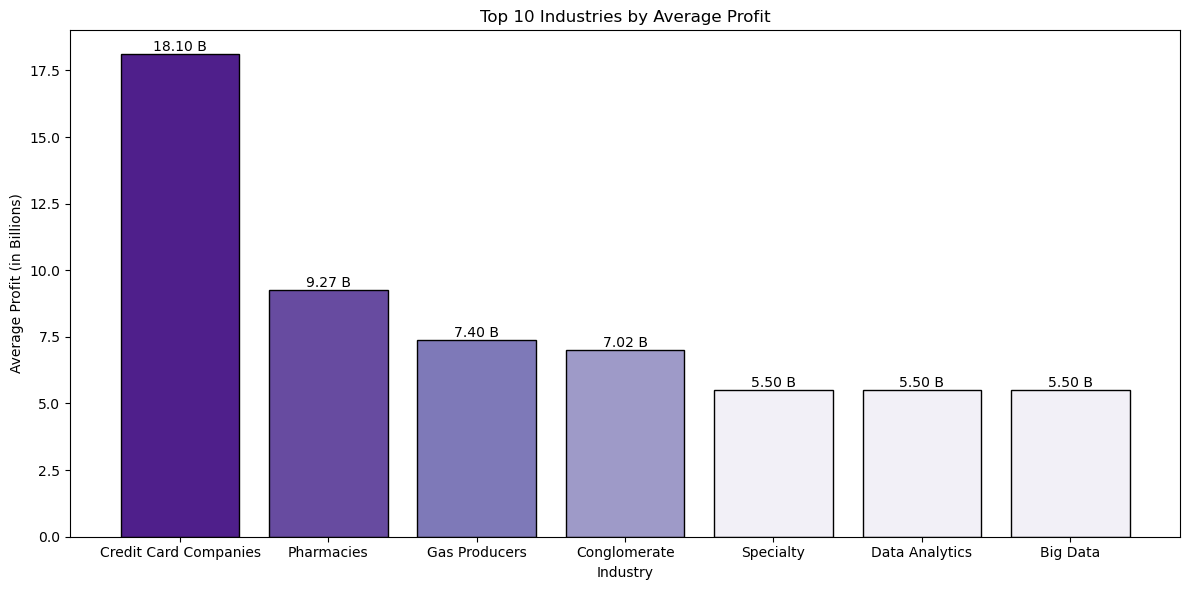

In [14]:
industry_profit= Counter()
industry_count= Counter()

for company, industries in industry_dict.items():
    profit = df.loc[df['Name']== company, 'Profit'].values[0]
    for industry in industries:
        industry_profit[industry] += profit
        industry_count[industry] += 1
        
average_profit = {industry: industry_profit[industry]/industry_count[industry] for industry in industry_profit}

sorted_avg_profit= sorted(average_profit.items(), key= lambda x: x[1], reverse=True)[:7]
industries, avg_profits= zip(*sorted_avg_profit)
normalized_colors= np.linspace(0.9, 0.1, len(avg_profits))
color_map = {profit: plt.cm.Purples(norm_val) for profit, norm_val in zip(avg_profits, normalized_colors)}
colors = [color_map[profit] for profit in avg_profits]

plt.figure(figsize=(12, 6))
bars = plt.bar(industries, avg_profits, color=colors, edgecolor='black')
plt.xlabel("Industry")
plt.ylabel("Average Profit (in Billions)")
plt.title("Top 10 Industries by Average Profit")
plt.xticks(fontsize=10)

for bar, profit in zip(bars, avg_profits):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{profit:.2f} B', ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()

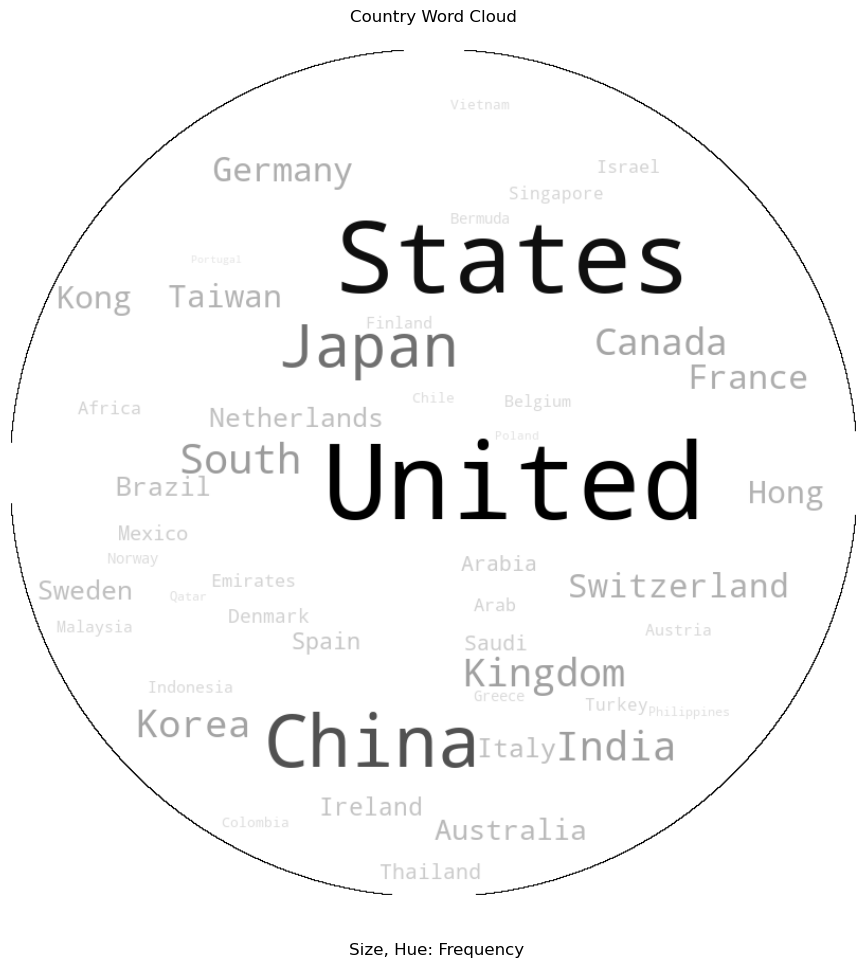

In [15]:
from wordcloud import WordCloud
x, y= np.ogrid[:800, :800]
mask= (x-400) ** 2 + (y-400) ** 2 > 400 ** 2
mask= 255 * mask.astype(int)

countries_text= " ".join(df['Country'].dropna().tolist())

wordcloud= WordCloud(width=800, height=800, background_color='white', max_font_size=100, min_font_size=10, mask=mask, contour_color='black', contour_width=1, margin=2, prefer_horizontal=1, collocations=False).generate(countries_text)

def grey_color_func(word, font_size, position, orientation, random_state= None, **kwargs):
    darkness= int (255 * (1- (font_size/100)))
    return f"rgb({darkness}, {darkness}, {darkness})"
wordcloud= wordcloud.recolor(color_func=grey_color_func)

plt.figure(figsize=(11,11))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Country Word Cloud", pad=20)
plt.text(320, 850,"Size, Hue: Frequency", fontsize=12, verticalalignment='center')
plt.show()

c:\Users\samar\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\samar\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


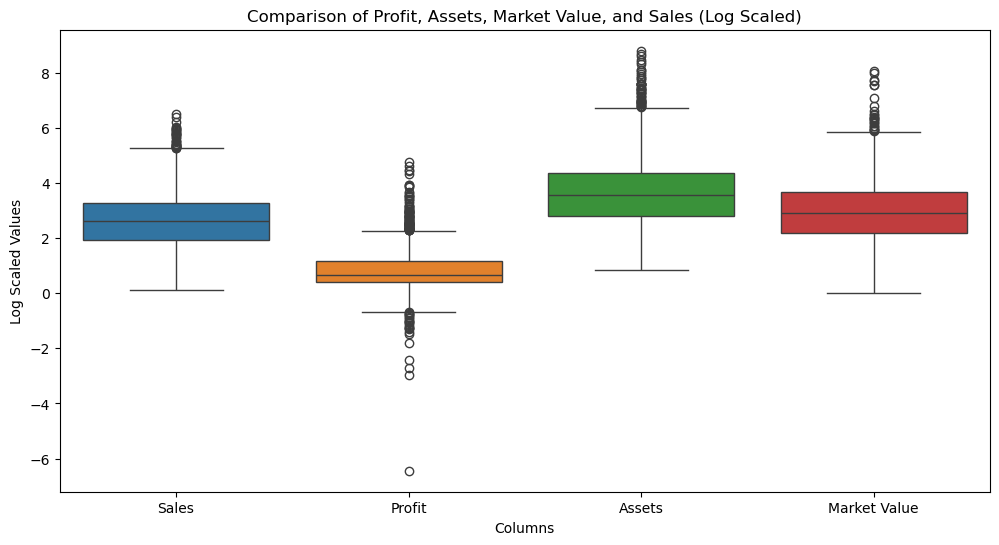

In [16]:
import seaborn as sns

df_scaled = df[['Sales' ,'Profit', 'Assets', 'Market Value' ]].apply(lambda x: np.log1p(x))

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled)
plt.title("Comparison of Profit, Assets, Market Value, and Sales (Log Scaled)")
plt.ylabel("Log Scaled Values")
plt.xlabel("Columns")
plt.show()

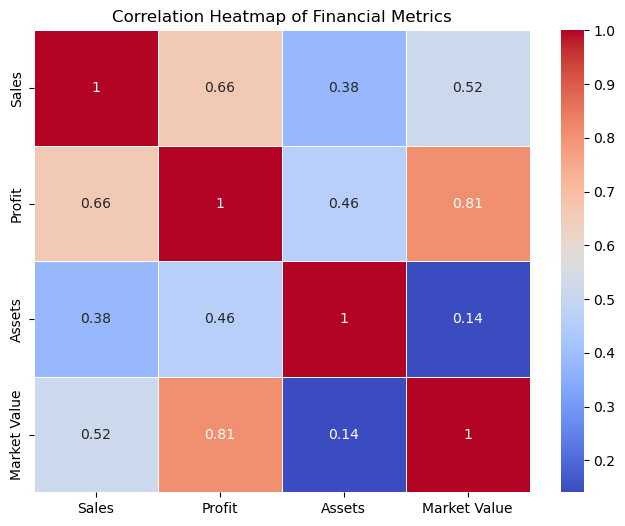

In [17]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[['Sales', 'Profit', 'Assets', 'Market Value']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Financial Metrics")
plt.show()